# 1 - Merge Sort - Complexidade O(n log n)

In [ ]:
# 1 - Divide a lista em duas partes
# 2 - Ordena cada parte
# 3 - Intercala as listas ordenadas
def merge_sort(lista):
    # Caso base (lista com 0 ou 1 elemento já está ordenada)
    if len(lista) == 1:
        return lista

    # Dividir a lista no meio
    meio = len(lista) // 2
    esquerda = lista[:meio]   # inicio --> meio
    direita = lista[meio:]    # meio até o meio

    # Ordenar recursivamente
    esquerda = merge_sort(esquerda)
    direita = merge_sort(direita)

    # Intercalar as listas ordenadas
    return intercalar(esquerda, direita)

# ----------------------------------------------------------------------------------------
# Recebe duas listas já ordenadas
def intercalar(esquerda, direita):
    #print(f'{esquerda}\n{direita}')
    resultado = []      # guarda os números ordenados.
    i = j = 0           # i posição a esquerda da lista, j	a direita

    # Comparar enquanto ainda existir elementos nas duas listas (esquerda e direita)
    while i < len(esquerda) and j < len(direita):
        # Comparas os elementos atuais das duas listas
        if esquerda[i] < direita[j]:
            resultado.append(esquerda[i])   # esquerda menor > adiciona valor no final da lista
            i += 1                          # avança índice da esquerda
        else:
            resultado.append(direita[j])    # direita menor > adiciona valor no final da lista
            j += 1                          # avança índice da direita

    # Adicionar elementos restantes
    resultado.extend(esquerda[i:])          # adiciona itens que sobraram após o while na lista esquerda
    resultado.extend(direita[j:])           # adiciona itens que sobraram após o while na lista direita

    return resultado                        # Retorna a lista final ordenada.


# TESTANDO
lista = [3, 2, 4, 9, 1, 5, 7]
ordenada = merge_sort(lista)

print(f'Lista Original: {lista}')
print(f'Lista Ordenada: {ordenada}')

Lista Original: [3, 2, 4, 9, 1, 5, 7]
Lista Ordenada: [1, 2, 3, 4, 5, 7, 9]


# 2 - Quick Sort - Complexidade O(n log n) ou O(n²)

In [ ]:
# 1 - Escolhe um elemento da lista como pivô
# 2 - Divide a lista em 2 o 3 partes:
#     menores ou iguais ao pivô e maiores que o pivô
# 3 - Ordena recursivamente as partes menores e maiores
# 4 - Junta: menores ordenados + pivôs + maiores ordenados
def quick_sort(lista):
    # CASO BASE: se a lista tem 0 ou 1 elemento, ela já está ordenada
    if len(lista) <= 1:
        return lista

    pivo = lista[0]     # Escolhe o primeiro elemento da lista como pivô

    # Cria listas menores com list comprehension
    # "x for x in lista[1:]"" percorre todos os elementos da lista exceto o pivô "lista[1:]"
    # "if x <= pivo" Filtra valores menores ou iguais ao pivô
    menores = [x for x in lista[1:] if x <= pivo]

    #print(menores)
    # "if x > pivo" Filtra valores maiores que o pivô
    maiores = [x for x in lista[1:] if x > pivo]
    #print(maiores)

    # Recursão: ordena recursivamente as listas menores e maiores
    # "quick_sort(menores)" Ordena os números menores que o pivô
    # "quick_sort(maiores)" Ordena os números maiores que o pivô
    return quick_sort(menores) + [pivo] + quick_sort(maiores)


# TESTANDO
lista = [8, 27, 5, 43, 91, 5, 8, 10, 5, 8, 5, 7]
ordenado = quick_sort(lista)

print(f'Lista Original: {lista}')
print(f'Lista Ordenada: {ordenado}')

Lista Original: [8, 27, 5, 43, 91, 5, 8, 10, 5, 8, 5, 7]
Lista Ordenada: [5, 5, 5, 5, 7, 8, 8, 8, 10, 27, 43, 91]


#
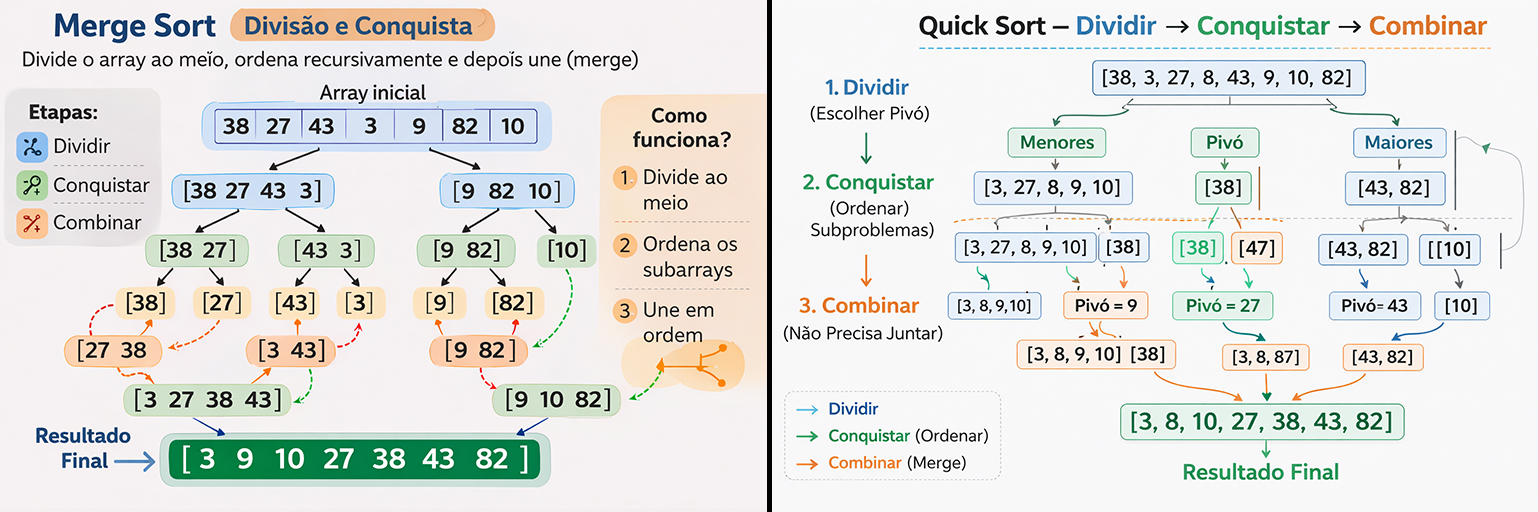

# 3 - Quick Select - Complexidade O(n) ou O(n²)

In [ ]:
# QuickSort continua ordenando as duas partes,
# QuickSelect continua apenas na parte onde está o elemento desejado.

# 1 - Escolhe um elemento da lista como pivô
# 2 - Particiona a lista em menores ou iguais ao pivô e maiores que o pivô
# 3 - Coloca o pivô na posição correta que teria se a lista estivesse ordenada
# 4 - Verifica se o pivô é o k-ésimo elemento procurado
# 5 - Continua recursivamente apenas no lado da lista onde o k-ésimo elemento pode estar
def particao(lista, esq, dir):
    pivo = lista[dir]  # escolhe o último elemento da lista como pivô
    i = esq - 1        # índice que indica a posição final dos elementos menores que o pivô

    # percorre a lista do índice 'esq' até 'dir-1'
    for j in range(esq, dir):
        # se o elemento atual for menor ou igual ao pivô
        if lista[j] <= pivo:
            i += 1  # avança o índice dos menores
            # troca o elemento atual com o elemento na posição i
            # isso move o valor menor que o pivô para a parte esquerda da lista
            lista[i], lista[j] = lista[j], lista[i]

    # após percorrer todos os elementos, coloca o pivô na posição correta
    # todos os elementos menores ficam à esquerda e os maiores à direita
    lista[i + 1], lista[dir] = lista[dir], lista[i + 1]

    # retorna o índice final onde o pivô foi colocado
    return i + 1


# Função principal do QuickSelect que encontra o k-ésimo menor elemento
def quickselect(lista, esq, dir, k):
    k -= 1              # converte k da forma "humana" (1º, 2º, 3º...) para índice da lista (0,1,2...)
    if esq <= dir:      # verifica se ainda existe uma parte válida da lista para analisar

        # chama a função de partição para reorganizar a lista e obter a posição final do pivô
        pivo_index = particao(lista, esq, dir)

        # se a posição do pivô for exatamente k, encontramos o k-ésimo menor elemento
        if pivo_index == k:
            return lista[pivo_index]

        # se a posição do pivô for maior que k, então o elemento procurado está na parte esquerda da lista
        elif pivo_index > k:
            return quickselect(lista, esq, pivo_index - 1, k)
        else:                                                       # caso contrário, o elemento está na parte direita da lista
            return quickselect(lista, pivo_index + 1, dir, k + 1)

    return None         # caso a busca não encontre o elemento (situação limite)


# ---------------------- EXEMPLO DE USO ----------------------
teste = [6, 4, 7, 1, 3, 8, 5, 2]
k_esimo = 6         # queremos encontrar o 6º menor elemento da lista

resultado = quickselect(teste, 0, len(teste) - 1, k_esimo)
print(f"O {k_esimo}º elemento da lista é o {resultado}")

O 6º elemento da lista é o 6


# 4 - Strassen - Complexidade [n^2.81]

In [ ]:
# 1 - A matriz é separada em 4 elementos (submatrizes 1x1 no caso 2x2).
# 2 - Calculam-se 7 produtos intermediários M1 a M7.
# 3 - Combina-se esses produtos para formar a matriz final.
# recebe duas matrizes
def strassen(A, B):
    """
    Multiplicação de matrizes 2x2 usando o Algoritmo de Strassen.
    A e B são listas de listas 2x2.
    """
    # Caso base: matriz 1x1 --> O produto(multiplicação) é direto
    if len(A) == 1:
        return [[A[0][0] * B[0][0]]]

    # Separar submatrizes, pegando os elementos individuais de cada matriz 2x2
    a, b, c, d = A[0][0], A[0][1], A[1][0], A[1][1]
    e, f, g, h = B[0][0], B[0][1], B[1][0], B[1][1]

    # Cálculo das 7 multiplicações intermediárias
    # Cada M combina elementos das matrizes de forma a reduzir o número de multiplicações de 8 (na multiplicação direta 2x2) para 7.
    M1 = (a + d) * (e + h)
    M2 = (c + d) * e
    M3 = a * (f - h)
    M4 = d * (g - e)
    M5 = (a + b) * h
    M6 = (c - a) * (e + f)
    M7 = (b - d) * (g + h)

    # Combinar os produtos intermediários (M1 a M7) para obter cada elemento da matriz
    # | C11  C12 |
    # | C21  C22 |
    C11 = M1 + M4 - M5 + M7
    C12 = M3 + M5
    C21 = M2 + M4
    C22 = M1 - M2 + M3 + M6

    return [[C11, C12], [C21, C22]]         # Retorna a matriz resultado final 2x2.


# TESTANDO
# Cria duas matrizes
A = [[1, 2],
     [3, 4]]

B = [[5, 6],
     [7, 8]]

resultado = strassen(A, B)
print("Resultado da multiplicação Strassen:")
# Imprime o resultado linha por linha, para ficar legível.
for linha in resultado:
    print(linha)

Resultado da multiplicação Strassen:
[19, 22]
[43, 50]


#
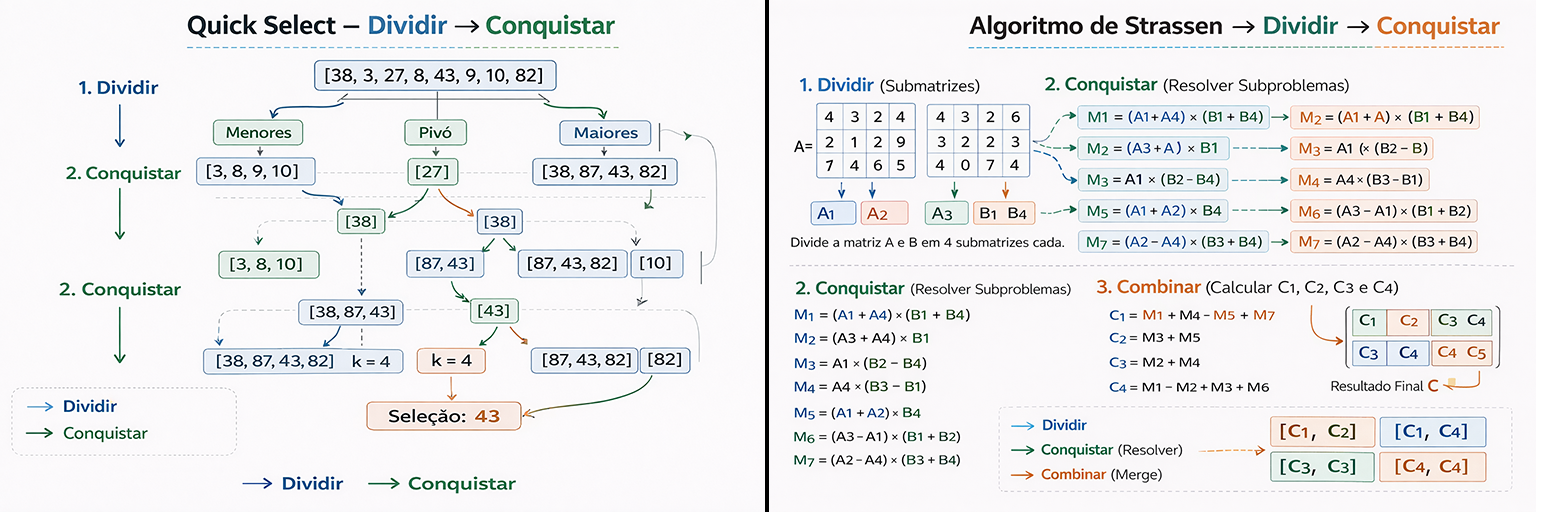